# Proyek Klasifikasi Gambar: Skin Condition Classification (Acne, Eczema, Psoriasis, Normal Skin)

## Import Semua Packages/Library yang Digunakan

In [1]:
# Upload file dari lokal ke Colab
from google.colab import files
files.upload()

# Menginstal library kaggle di Google Colab
!pip install kaggle

# Data Exploration
import os
import matplotlib.pyplot as plt

# Split Dataset
import pandas as pd
from sklearn.model_selection import train_test_split

# ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Modelling
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, BatchNormalization, Conv2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Evaluasi dan Visualisasi
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

Saving kaggle.json to kaggle.json


## Data Preparation

### Data Loading

In [2]:
# Membuat folder .kaggle dan menyalin file API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# Mengunduh dataset dari Kaggle
!kaggle datasets download -d sufiahmad883/acne-psoriasis-eczema-vs-all-skin-diseases

Dataset URL: https://www.kaggle.com/datasets/sufiahmad883/acne-psoriasis-eczema-vs-all-skin-diseases
License(s): unknown
100% 6.62G/6.62G [01:32<00:00, 76.8MB/s]



In [4]:
# Mengekstrak file dataset yang telah diunduh
!unzip -q acne-psoriasis-eczema-vs-all-skin-diseases.zip

### Data Exploration

In [5]:
# Menampilkan daftar nama kelas dan jumlahnya dari folder dataset
image_dataset = 'Acne_Psoriasis_Eczema_vs_All_skin_Diseases'
excluded_classes = ['Other']   # kelas yang mau dibuang
classes = [cls for cls in os.listdir(image_dataset) if cls not in excluded_classes]
print("Kelas:", classes)
print("Jumlah kelas:", len(classes))

Kelas: ['Eczema', 'Psoriasis', 'ACNE', 'NORMAL SKIN']
Jumlah kelas: 4


In [6]:
# Jumlah gambar per kelas
class_counts = {cls: len(os.listdir(os.path.join(image_dataset, cls))) for cls in classes}
for cls, count in class_counts.items():
    print(f"{cls}: {count} gambar")

# Hitung total semua gambar
total_images = sum(class_counts.values())
print("\nTotal semua gambar:", total_images)

Eczema: 3200 gambar
Psoriasis: 3812 gambar
ACNE: 4198 gambar
NORMAL SKIN: 2158 gambar

Total semua gambar: 13368


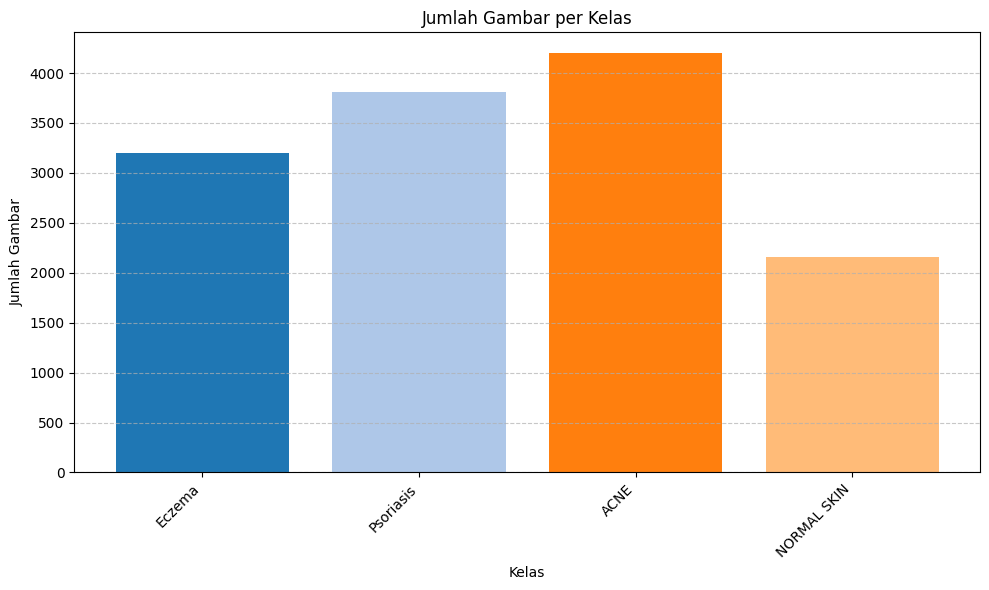

In [7]:
# Visualisasi dengan bar chart
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color=plt.cm.tab20.colors)
plt.title("Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel("Jumlah Gambar")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

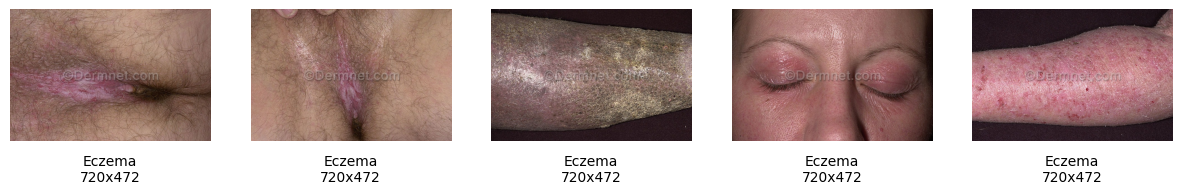

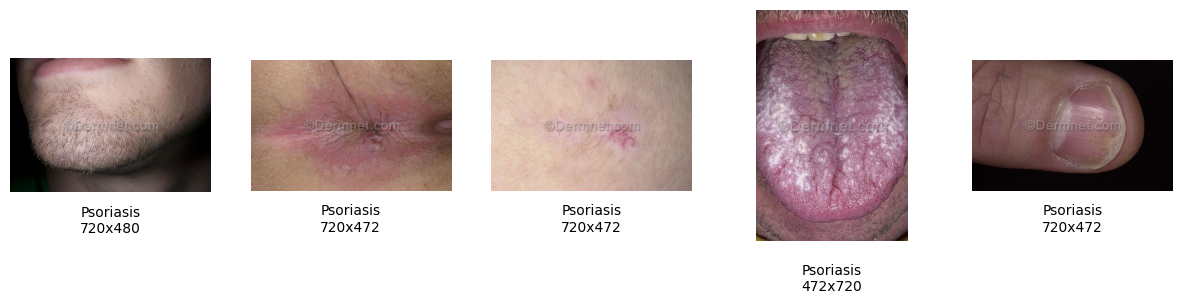

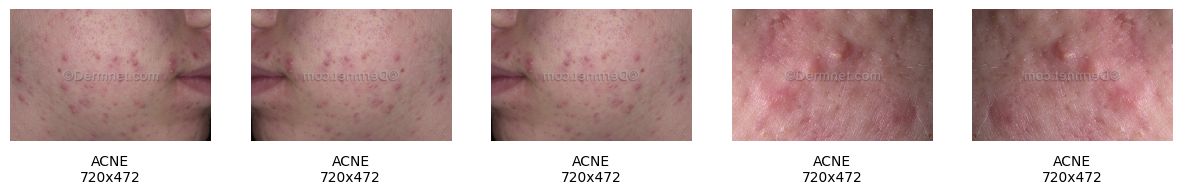

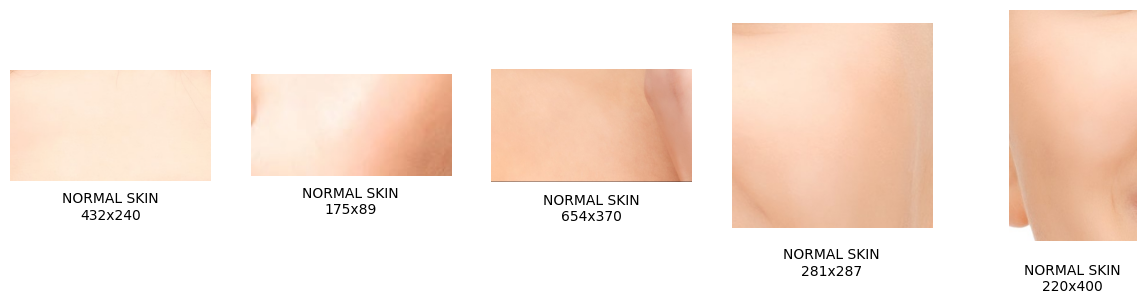

In [8]:
# Menampilkan beberapa contoh gambar dari tiap kelas
def display_images(image_dataset, classes, num_images=5):
    for cls in classes:
        class_path = os.path.join(image_dataset, cls)
        images = sorted(os.listdir(class_path))[:num_images]
        plt.figure(figsize=(15,3))
        for i, img_file in enumerate(images):
            img_path = os.path.join(class_path, img_file)
            img = plt.imread(img_path)
            height, width = img.shape[:2]
            plt.subplot(1, num_images, i+1)
            plt.imshow(img)
            plt.axis('off')
            # Tambahkan teks di bawah gambar
            plt.text(0.5, -0.1, f'{cls}\n{width}x{height}',
                     ha='center', va='top', transform=plt.gca().transAxes, fontsize=10)
        plt.show()

display_images(image_dataset, classes, num_images=5)

### Data Preprocessing

#### Split Dataset

In [9]:
data = []

for cls in classes:
    class_path = os.path.join(image_dataset, cls)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({'filepath': os.path.join(class_path, fname), 'label': cls})

df = pd.DataFrame(data)
print(df.sample(10))

                                                filepath        label
11872  Acne_Psoriasis_Eczema_vs_All_skin_Diseases/NOR...  NORMAL SKIN
10798  Acne_Psoriasis_Eczema_vs_All_skin_Diseases/ACN...         ACNE
2551   Acne_Psoriasis_Eczema_vs_All_skin_Diseases/Ecz...       Eczema
8525   Acne_Psoriasis_Eczema_vs_All_skin_Diseases/ACN...         ACNE
11828  Acne_Psoriasis_Eczema_vs_All_skin_Diseases/NOR...  NORMAL SKIN
12861  Acne_Psoriasis_Eczema_vs_All_skin_Diseases/NOR...  NORMAL SKIN
7983   Acne_Psoriasis_Eczema_vs_All_skin_Diseases/ACN...         ACNE
6408   Acne_Psoriasis_Eczema_vs_All_skin_Diseases/Pso...    Psoriasis
10603  Acne_Psoriasis_Eczema_vs_All_skin_Diseases/ACN...         ACNE
6682   Acne_Psoriasis_Eczema_vs_All_skin_Diseases/Pso...    Psoriasis


In [10]:
# Split 70% train, 30% sementara untuk val+test
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

# Split 30% tadi menjadi 50% val dan 50% test = masing-masing 15% total
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Jumlah tiap kelas
print("Train:")
print(train_df['label'].value_counts())
print("\nValidation:")
print(val_df['label'].value_counts())
print("\nTest:")
print(test_df['label'].value_counts())

Train:
label
ACNE           2938
Psoriasis      2668
Eczema         2240
NORMAL SKIN    1510
Name: count, dtype: int64

Validation:
label
ACNE           629
Psoriasis      572
Eczema         480
NORMAL SKIN    324
Name: count, dtype: int64

Test:
label
ACNE           630
Psoriasis      572
Eczema         480
NORMAL SKIN    324
Name: count, dtype: int64


#### ImageDataGenerator

In [11]:
target_size = (300, 300)   # ukuran input gambar (resolusi native EfficientNetB3)
batch_size = 32            # batch size

In [12]:
# Augmentasi untuk train
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,         # lebih ringan
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Untuk validation dan test, hanya preprocessing (tanpa augmentasi)
test_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Train
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Validation
val_generator = test_val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Test
test_generator = test_val_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 9356 validated image filenames belonging to 4 classes.
Found 2005 validated image filenames belonging to 4 classes.
Found 2006 validated image filenames belonging to 4 classes.


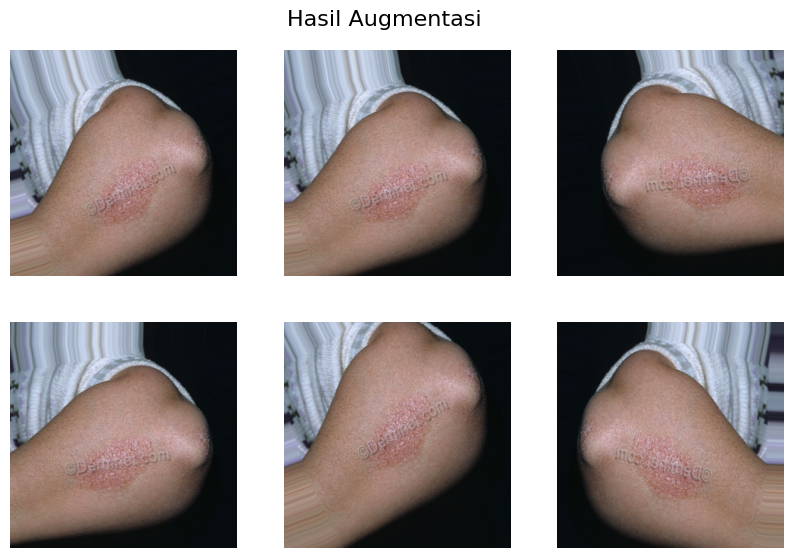

In [13]:
# Ambil satu batch dari train_generator
images, labels = next(train_generator)

# Pilih satu gambar dari batch
img = images[0]
label = np.argmax(labels[0])

# Buat generator augmentasi hanya untuk satu gambar
augmentation_generator = train_datagen.flow(
    np.expand_dims(img, axis=0),
    batch_size=1
)

# Visualisasi
plt.figure(figsize=(10, 10))
for i in range(6):
    batch = next(augmentation_generator)
    aug_img = batch[0]  # ambil gambar dari batch
    plt.subplot(3, 3, i+1)
    plt.imshow(aug_img / np.max(aug_img))
    plt.axis('off')
plt.suptitle(f'Hasil Augmentasi', fontsize=16,  y=0.92)
plt.show()

In [14]:
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(train_generator.classes),
                                     y=train_generator.classes)
class_weights = dict(enumerate(class_weights))

## Modelling

In [15]:
efficientnet = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

efficientnet.trainable = True

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Tentukan jumlah kelas dari generator
num_classes = len(train_generator.class_indices)

# Bangun model CNN dengan EfficientNetB3
model = Sequential([
    efficientnet,
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),
    Dense(num_classes, activation='softmax')
])

# Kompilasi model
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

# Callback
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Training model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 10, 10, 256)    │     3,539,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,687,283 (56.03 MB)

 Trainable params: 14,598,444 (55.69 MB)

 Non-trainable params: 88,839 (347.03 KB)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 618s 2s/step - accuracy: 0.5650 - loss: 1.2401 - val_accuracy: 0.7152 - val_loss: 0.6412 - learning_rate: 1.0000e-04
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.7245 - loss: 0.7249 - val_accuracy: 0.8359 - val_loss: 0.4182 - learning_rate: 1.0000e-04
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.7997 - loss: 0.5212 - val_accuracy: 0.8648 - val_loss: 0.3490 - learning_rate: 1.0000e-04
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 275s 938ms/step - accuracy: 0.8426 - loss: 0.3999 - val_accuracy: 0.8898 - val_loss: 0.3076 - learning_rate: 1.0000e-04
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 267s 911ms/step - accuracy: 0.8782 - loss: 0.3328 - val_accuracy: 0.9142 - val_loss: 0.2634 - learning_rate: 1.0000e-04
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 266s 907ms/step - accuracy: 0.9084 - loss: 0.2474 - val_accuracy: 0.9032 - val_loss: 0.2868 - learning_rate: 1.0000e-04
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 267s 909m

## Evaluasi dan Visualisasi

In [17]:
# Prediksi pada data validasi
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Label sebenarnya dari generator
y_true = val_generator.classes

# Nama kelas
class_labels = list(val_generator.class_indices.keys())

# Classification Report
print("Classification Report")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 348ms/step
Classification Report
              precision    recall  f1-score   support

        ACNE       0.98      0.97      0.97       629
      Eczema       0.91      0.94      0.92       480
 NORMAL SKIN       0.99      0.99      0.99       324
   Psoriasis       0.93      0.92      0.93       572

    accuracy                           0.95      2005
   macro avg       0.95      0.95      0.95      2005
weighted avg       0.95      0.95      0.95      2005



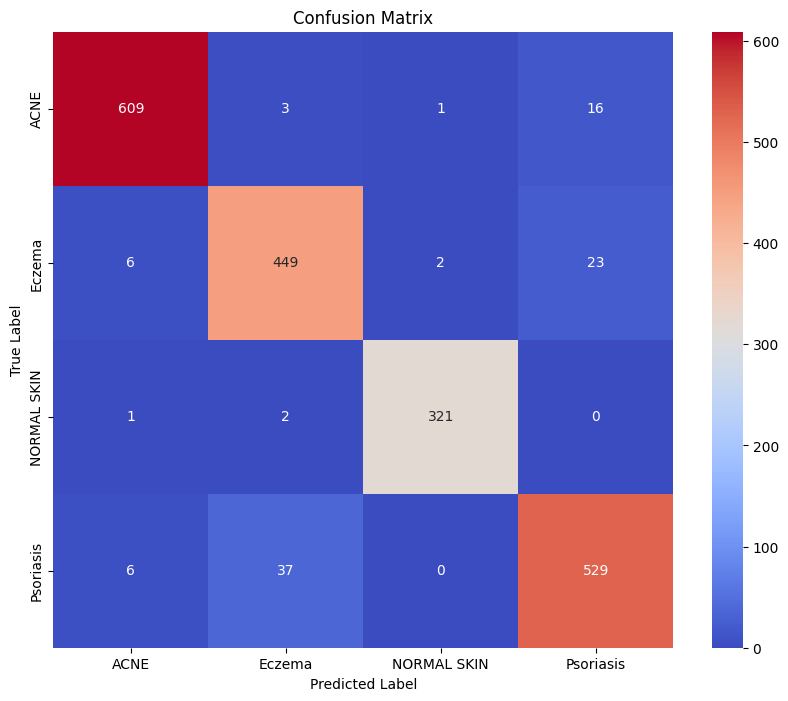

In [18]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

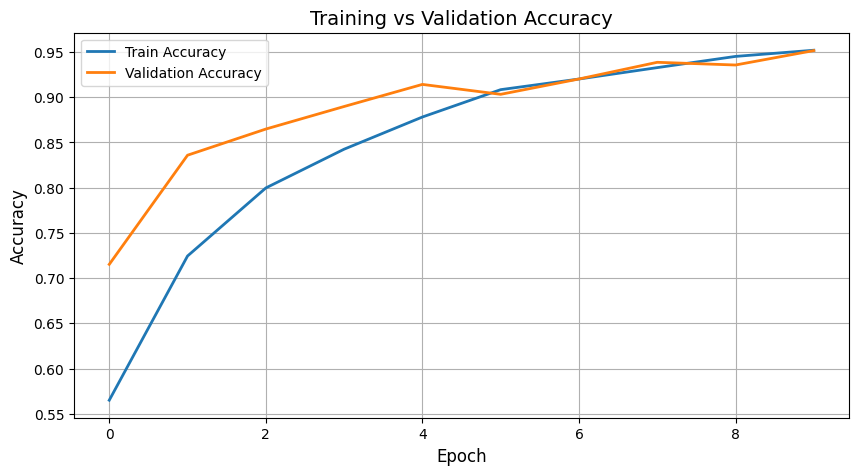

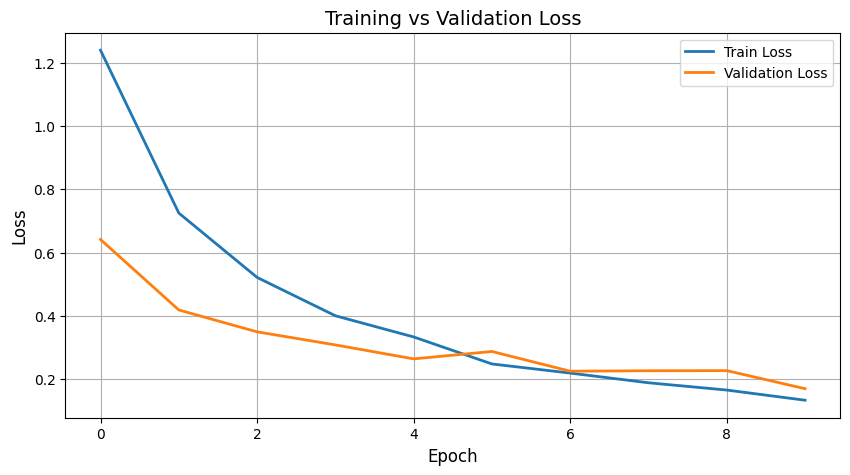

In [19]:
# Visualisasi
# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## Konversi Model

#### SavedModel

In [20]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor_385')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137711894692688: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137711894692112: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137713439445200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439445584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439454416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439450384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439445392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439454032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439444240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137713439453840: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [21]:
!zip -r saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.index (deflated 76%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/saved_model.pb (deflated 91%)
  adding: saved_model/fingerprint.pb (stored 0%)


In [29]:
!pip freeze > requirements.txt

## Kesimpulan

Berdasarkan hasil training model EfficientNetB3 pada 10 epoch, model mencapai train accuracy 95,20% (loss 0,1326) dan validation accuracy 95,16% (val_loss 0,1691), menunjukkan model belajar dengan baik tanpa overfitting signifikan (gap train-val kecil). Dari classification report pada data validasi, model mencapai akurasi keseluruhan 95%, dengan performa terbaik pada kelas normal skin (precision 0,99, recall 0,99, f1-score 0,99) dan acne (precision 0,98, recall 0,97, f1-score 0,97).